In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.simplefilter('ignore')

In [3]:
train=pd.read_csv("data/train.csv")
test=pd.read_csv("data/test.csv")
train.head()

,price_tnd,location,city,governorate,Area,pieces,room,bathroom,age,state,...,concierge,beach_view,mountain_view,pool,elevator,furnished,equipped_kitchen,central_heating,air_conditioning,Id
0,2000000.0,Sousse Corniche,Sousse Ville,Sousse,932.0,24.0,24.0,10.0,NaN,1.0,...,0,0,0,0,0,1,1,1,1,2
1,2000000.0,Sousse Corniche,Sousse Ville,Sousse,932.0,24.0,24.0,NaN,NaN,NaN,...,0,0,0,0,0,1,1,1,1,3
2,2000000.0,Sousse Corniche,Sousse Ville,Sousse,932.0,24.0,24.0,10.0,NaN,1.0,...,0,0,0,0,0,1,1,1,1,4
3,1200000.0,Midoun,NaN,Djerba,370.0,21.0,9.0,5.0,NaN,NaN,...,0,0,0,1,0,0,0,0,0,6
4,3200000.0,El Kantaoui,Hammam Sousse,Sousse,1899.0,20.0,5.0,7.0,NaN,1.0,...,0,0,0,1,0,0,1,1,1,7


In [4]:
#DATA PREPROCESSING
df=train.dropna()
# Get list of categorical variables
s = (df.dtypes == 'object')
object_cols = list(s[s].index)

print("Categorical variables:")
print(object_cols)
# create label encoder
lee = LabelEncoder()

# fit and transform label encoder on a categorical column
for col in object_cols :
    df[col] = lee.fit_transform(df[col])
    test[col] = lee.fit_transform(test[col])
df.head()

Categorical variables:
['location', 'city', 'governorate', 'age']


,price_tnd,location,city,governorate,Area,pieces,room,bathroom,age,state,...,concierge,beach_view,mountain_view,pool,elevator,furnished,equipped_kitchen,central_heating,air_conditioning,Id
3959,550000.0,170,28,5,650.0,4.0,3.0,3.0,0,2.0,...,0,0,0,1,0,0,1,0,0,2029
3960,650000.0,126,21,2,444.0,4.0,3.0,2.0,2,0.0,...,0,0,0,0,0,0,0,0,0,2100
3961,809300.0,92,10,5,180.0,5.0,2.0,2.0,6,1.0,...,0,1,0,1,0,1,1,0,1,1771
3962,500000.0,171,53,13,800.0,7.0,5.0,2.0,4,1.0,...,0,0,0,0,0,0,1,0,1,459
3963,2000000.0,153,34,1,452.0,5.0,4.0,3.0,1,2.0,...,0,0,1,1,0,0,1,1,1,1323


In [5]:
idd = test['Id']
y=df['price_tnd']
X=df.drop('price_tnd',axis=1)
X.drop('Id',axis=1,inplace=True)
test.drop('Id',axis=1,inplace=True)
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=50)

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error


# Train the Random Forest Regressor
regr = RandomForestRegressor(n_estimators=100, random_state=42)
regr.fit(X_train, y_train)

# Predict using the test data
y_pred = regr.predict(X_test)

# Calculate the root mean squared error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error:",rmse)

Root Mean Squared Error: 723945.5069516383


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Params: {'max_depth': 32, 'max_features': None, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 541}

Evaluation Metrics:


,Metric,Value
0,MAE,2.126001e+05
1,MSE,4.840738e+11
2,RMSE,6.957542e+05
3,R2,4.373676e-01
4,Adjusted R2,3.969283e-01
5,MAPE (%),3.355745e+01
6,Median AE,7.852755e+04
7,Explained Variance,4.376993e-01
8,CV RMSE Mean,5.091736e+05
9,CV RMSE Std,2.261319e+05


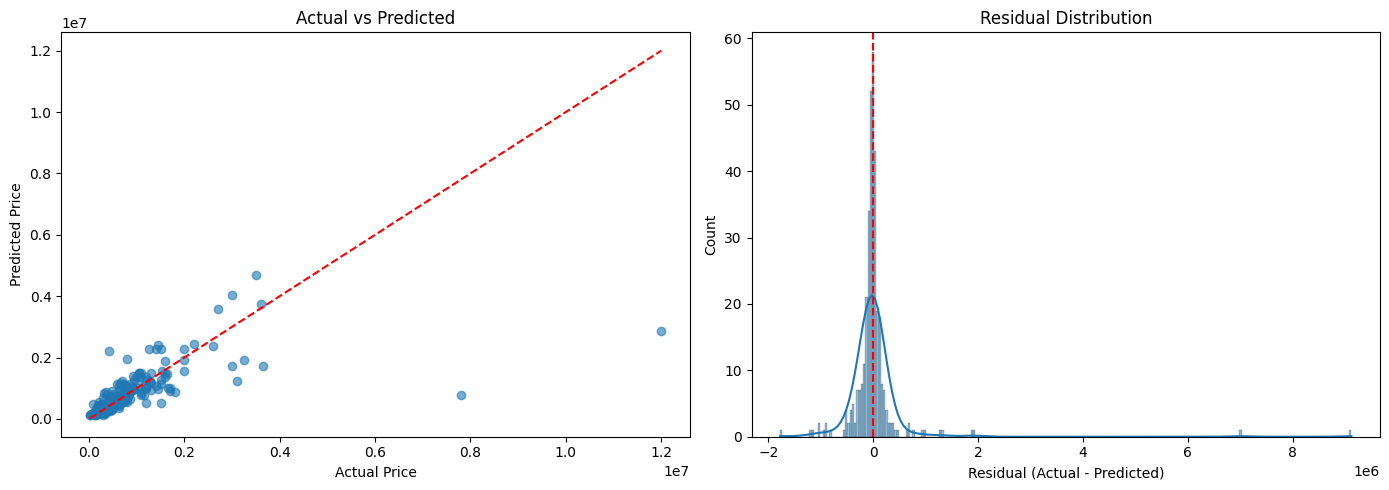

In [8]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    median_absolute_error,
    explained_variance_score,
)
from sklearn.model_selection import RandomizedSearchCV, KFold, cross_val_score
from scipy.stats import randint

# --- Model improvement: hyperparameter tuning ---
param_dist = {
    "n_estimators": randint(150, 700),
    "max_depth": [None] + list(range(6, 36, 2)),
    "min_samples_split": randint(2, 15),
    "min_samples_leaf": randint(1, 8),
    "max_features": ["sqrt", "log2", None],
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_
regr = best_model  # keep the same variable name for submission cell

y_pred = regr.predict(X_test)

# --- Rich evaluation metrics ---
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
medae = median_absolute_error(y_test, y_pred)
ev = explained_variance_score(y_test, y_pred)

# Safe MAPE (avoid division by zero)
y_test_safe = np.where(y_test == 0, 1e-8, y_test)
mape = np.mean(np.abs((y_test - y_pred) / y_test_safe)) * 100

# Adjusted R2
n = len(y_test)
p = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1) if n > p + 1 else np.nan

# Cross-validated RMSE on the train split
cv_rmse_scores = -cross_val_score(
    regr,
    X_train,
    y_train,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

metrics_df = pd.DataFrame(
    {
        "Metric": [
            "MAE",
            "MSE",
            "RMSE",
            "R2",
            "Adjusted R2",
            "MAPE (%)",
            "Median AE",
            "Explained Variance",
            "CV RMSE Mean",
            "CV RMSE Std",
        ],
        "Value": [
            mae,
            mse,
            rmse,
            r2,
            adj_r2,
            mape,
            medae,
            ev,
            cv_rmse_scores.mean(),
            cv_rmse_scores.std(),
        ],
    }
)

print("Best Params:", random_search.best_params_)
print("\nEvaluation Metrics:")
display(metrics_df)

# --- Evaluation plots ---
residuals = y_test - y_pred

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True)
plt.axvline(0, color="red", linestyle="--")
plt.title("Residual Distribution")
plt.xlabel("Residual (Actual - Predicted)")

plt.tight_layout()
plt.show()

In [ ]:
final_preds=regr.predict(test)
submit=pd.DataFrame()
submit['ID']=idd
submit['price_tnd']=final_preds

submit.head()
submit['price_tnd']=submit['price_tnd'].astype('int')
submit.head()


In [10]:
import os
import joblib

# Save trained model + useful metadata for inference
os.makedirs("artifacts", exist_ok=True)

model_artifact = {
    "model": regr,
    "feature_columns": X_train.columns.tolist(),
    "target": "price_tnd",
}

joblib.dump(model_artifact, "artifacts/price_model.joblib")
print("Saved: artifacts/price_model.joblib")


Saved: artifacts/price_model.joblib
